In [3]:
# Импорты и загрузка данных
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style='whitegrid')

# Отображение pandas без обрезки
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

if '../src' not in sys.path:
    sys.path.append('../src')
from database import load_worst_corrosion_by_component as load_data

DF_full = load_data()

In [5]:
# Целевая переменная
TARGET = 'corr_rate_worst_mm_per_year'

assert TARGET in DF_full.columns, f'В данных отсутствует {TARGET}'

print(f"Полный датасет: {len(DF_full):,} строк, {len(DF_full.columns)} колонок")
print('Колонки:', sorted(DF_full.columns.tolist()))

Полный датасет: 36,093 строк, 62 колонок
Колонки: ['ammonia_content', 'ammonium_chloride_content', 'avg_corr_rate_mm_per_year', 'chloride_aggressiveness', 'chlorine_content', 'co2_content', 'component', 'component_id', 'component_type', 'component_type_code', 'contour', 'corr_rate_worst_mm_per_year', 'corrosion_aggressiveness_index', 'corrosion_inhibitor_content', 'corrosion_protection_index', 'cross_section_area_mm2', 'curr_measurement_date', 'curr_thickness_avg_mm', 'curr_thickness_worst_mm', 'delta_years', 'effective_start_date', 'equipment', 'equipment_age_years', 'equipment_id', 'h2s_aggressiveness_index', 'h2s_content', 'h2s_water_ratio', 'hydrochloric_acid_content', 'initial_thickness', 'inner_diameter', 'installation', 'installation_id', 'material_code', 'material_code_id', 'material_grade', 'material_resistance_score', 'material_type', 'max_corr_rate_mm_per_year', 'min_corr_rate_mm_per_year', 'nominal_eff', 'nominal_thickness_mmc', 'num_points_in_section', 'num_sections', 'out

In [58]:
# Фильтр по установкам
# 54 - АВТ-6, 68 - АВТ-2, 53 - АВТ-1, 80 - АВТ-5, 4 - KK-2, 51 - КК
INSTALLATION_IDS = [4,51,80,53,68,54]

DF_loaded = DF_full[DF_full['installation_id'].isin(INSTALLATION_IDS)].copy()
DF_loaded = DF_loaded.sort_values('installation_id').reset_index(drop=True)
print(f"Отфильтровано (installation_id in {INSTALLATION_IDS}): {len(DF_loaded):,} строк")

# Пустые в числовых признаках = 0; цель не заполняем
num_cols = [c for c in DF_loaded.select_dtypes(include=[np.number]).columns if c != TARGET]
DF_loaded[num_cols] = DF_loaded[num_cols].fillna(0)

print("Распределение по установкам:")
print(DF_loaded['installation_id'].value_counts().sort_index())

Отфильтровано (installation_id in [4, 51, 80, 53, 68, 54]): 36,093 строк
Распределение по установкам:
installation_id
4     6951
51    7529
53    3908
54    9929
68    3772
80    4004
Name: count, dtype: int64


In [94]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error


def run_random_forest(df, features, target,
                      test_size=0.2, n_estimators=100,
                      max_depth=10, random_state=42):
    """
    Обучает RandomForest на df[features] -> df[target].
    Возвращает (model, metrics_df) — обученную модель и таблицу метрик.
    """
    features = [c for c in features if c in df.columns]
    df_reg = df[features + [target]].dropna(subset=[target]).copy()
    n_samples = len(df_reg)
    if n_samples < 10:
        raise ValueError(
            f"Слишком мало строк с заданной целью ({n_samples}). "
            f"Проверьте колонку {target}"
        )

    X = df_reg[features]
    y = df_reg[target]
    ts = test_size if n_samples >= 50 else max(0.15, 2 / n_samples)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=ts, random_state=random_state
    )

    model = RandomForestRegressor(
        n_estimators=n_estimators,
        max_depth=max_depth,
        random_state=random_state
    )
    model.fit(X_train, y_train)

    y_pred_train = model.predict(X_train)
    y_pred_test  = model.predict(X_test)

    r2_tr   = round(r2_score(y_train, y_pred_train), 4)
    mae_tr  = round(mean_absolute_error(y_train, y_pred_train), 6)
    rmse_tr = round(np.sqrt(mean_squared_error(y_train, y_pred_train)), 6)

    r2_te   = round(r2_score(y_test, y_pred_test), 4)
    mae_te  = round(mean_absolute_error(y_test, y_pred_test), 6)
    rmse_te = round(np.sqrt(mean_squared_error(y_test, y_pred_test)), 6)

    columns = pd.MultiIndex.from_tuples([
        ('Признаки', ''),
        ('Метрики на обучении:', 'R²'),
        ('Метрики на обучении:', 'MAE'),
        ('Метрики на обучении:', 'RMSE'),
        ('Метрики на тесте:', 'R²'),
        ('Метрики на тесте:', 'MAE'),
        ('Метрики на тесте:', 'RMSE'),
    ])

    metrics_df = pd.DataFrame(
        [[', '.join(features),
          r2_tr, mae_tr, rmse_tr,
          r2_te, mae_te, rmse_te]],
        columns=columns
    )
    metrics_df.index = ['']

    return model, metrics_df


def show_metrics(df):
    """Отображение таблицы метрик без обрезки текста."""
    return df.style.set_properties(**{
        'text-align': 'left',
        'white-space': 'nowrap',
    })

In [95]:
FEATURES = [
    'equipment_age_years',
    'cross_section_area_mm2',
    'nominal_thickness_mmc',
    'h2s_water_ratio'
]
# Случайный лес (регрессия)
model, metrics_df = run_random_forest(DF_loaded, FEATURES, TARGET)
show_metrics(metrics_df)

In [96]:
FEATURES = [
    'equipment_age_years',
    'cross_section_area_mm2',
    'nominal_thickness_mmc',
    'h2s_water_ratio']
# Случайный лес (регрессия)
model, metrics_df = run_random_forest(DF_loaded, FEATURES, TARGET)
show_metrics(metrics_df)

In [97]:
# Сравнение: с equipment_age_years и без
FEATURES_no_age = [f for f in FEATURES if f != 'equipment_age_years']

_, metrics_with    = run_random_forest(DF_loaded, FEATURES, TARGET)
_, metrics_without = run_random_forest(DF_loaded, FEATURES_no_age, TARGET)

comparison = pd.concat([metrics_with, metrics_without], ignore_index=True)
comparison.index = ['с equipment_age_years', 'без equipment_age_years']
show_metrics(comparison)

In [98]:
# Сравнение бинирования equipment_age_years с разным шагом
age_col = 'equipment_age_years'
BIN_STEPS = [0.1, 0.5, 1.0, 2.0, 5.0]

rows = []
labels = []

# Оригинальный float
_, m_orig = run_random_forest(DF_loaded, FEATURES, TARGET)
rows.append(m_orig)
labels.append(f'float (уник. {DF_loaded[age_col].nunique()})')

for step in BIN_STEPS:
    col_name = f'equipment_age_bin_{step}'
    DF_loaded[col_name] = (DF_loaded[age_col] / step).round(0) * step
    feats_bin = [col_name if f == age_col else f for f in FEATURES]
    _, m_bin = run_random_forest(DF_loaded, feats_bin, TARGET)
    rows.append(m_bin)
    labels.append(f'бин {step} лет (уник. {DF_loaded[col_name].nunique()})')

comparison = pd.concat(rows, ignore_index=True)
comparison.index = labels
show_metrics(comparison)

In [99]:
# Проверка гипотезы: утечка данных через комбинацию age + nominal
# Скорость коррозии ≈ Δtолщина / Δвремя → age и nominal вместе восстанавливают цель
leak_tests = {
    'только equipment_age_years':       ['equipment_age_years'],
    'только nominal_thickness_mmc':     ['nominal_thickness_mmc'],
    'только nominal_eff':               ['nominal_eff'],
    'age + nominal_thickness_mmc':      ['equipment_age_years', 'nominal_thickness_mmc'],
    'age + nominal_eff':                ['equipment_age_years', 'nominal_eff'],
    'все FEATURES (с age)':             FEATURES,
    'все FEATURES (без age и nominal)': [f for f in FEATURES
                                         if f not in ('equipment_age_years',
                                                      'nominal_thickness_mmc',
                                                      'nominal_eff')],
}

rows = []
labels = []
for label, feats in leak_tests.items():
    feats_valid = [f for f in feats if f in DF_loaded.columns]
    if not feats_valid:
        continue
    _, m = run_random_forest(DF_loaded, feats_valid, TARGET)
    rows.append(m)
    labels.append(label)

leak_comparison = pd.concat(rows, ignore_index=True)
leak_comparison.index = labels
show_metrics(leak_comparison)

In [110]:
# Forward feature selection: жадно добавляем лучший признак на каждом шаге
from itertools import combinations

CANDIDATES = [
    'delta_years',
    'nominal_eff',
    'component_type_code',
    'material_resistance_score',
    'cross_section_area_mm2',
    'sodium_hydroxide_content',
    'total_sulfur_compounds',
    'oxygen_content',
    'h2s_content',
    'h2s_aggressiveness_index',
    'h2s_water_ratio',
    'co2_content',
    'corrosion_inhibitor_content',
    'chloride_aggressiveness',
    'ammonia_content',
    'total_acidity_index',
    'chlorine_content',
    'water_content',
]
CANDIDATES = [c for c in CANDIDATES if c in DF_loaded.columns]

selected = []
remaining = list(CANDIDATES)
results_rows = []

print("Forward selection — добавляем признак, максимизирующий R² на тесте:\n")

for step in range(len(CANDIDATES)):
    best_r2_test = -np.inf
    best_feat = None
    best_metrics = None

    for feat in remaining:
        trial = selected + [feat]
        _, m = run_random_forest(DF_loaded, trial, TARGET, n_estimators=50)
        # извлекаем R² на тесте из DataFrame
        r2_test_val = m[('Метрики на тесте:', 'R²')].values[0]
        if r2_test_val > best_r2_test:
            best_r2_test = r2_test_val
            best_feat = feat
            best_metrics = m

    # Если добавление нового признака не улучшает — остановка
    prev_best = results_rows[-1][1] if results_rows else -np.inf
    if best_r2_test <= prev_best and step > 0:
        print(f"\nШаг {step+1}: добавление любого признака не улучшает R² на тесте → СТОП")
        break

    selected.append(best_feat)
    remaining.remove(best_feat)
    results_rows.append((best_metrics, best_r2_test))
    print(f"Шаг {step+1}: + {best_feat:<35s}  →  R²(тест) = {best_r2_test}")

print(f"\nИтоговый набор ({len(selected)} признаков): {selected}")

# Сводная таблица по шагам
summary = pd.concat([r[0] for r in results_rows], ignore_index=True)
summary.index = [f'Шаг {i+1}' for i in range(len(results_rows))]
summary.style.set_properties(**{
    'text-align': 'left',
    'white-space': 'nowrap',
})

Forward selection — добавляем признак, максимизирующий R² на тесте:

Шаг 1: + component_type_code                  →  R²(тест) = 0.0061
Шаг 2: + nominal_eff                          →  R²(тест) = 0.0102
Шаг 3: + delta_years                          →  R²(тест) = 0.1539
Шаг 4: + total_sulfur_compounds               →  R²(тест) = 0.1708
Шаг 5: + corrosion_inhibitor_content          →  R²(тест) = 0.1748
Шаг 6: + material_resistance_score            →  R²(тест) = 0.1792

Шаг 7: добавление любого признака не улучшает R² на тесте → СТОП

Итоговый набор (6 признаков): ['component_type_code', 'nominal_eff', 'delta_years', 'total_sulfur_compounds', 'corrosion_inhibitor_content', 'material_resistance_score']


In [111]:
# Стратификация по установкам: forward selection для каждой отдельно
# 54 - АВТ-6, 68 - АВТ-2, 53 - АВТ-1, 80 - АВТ-5, 4 - KK-2, 51 - КК
INSTALL_NAMES = {4: 'КК-2', 51: 'КК', 53: 'АВТ-1', 54: 'АВТ-6', 68: 'АВТ-2', 80: 'АВТ-5'}

CANDIDATES = [
    'delta_years',
    'nominal_eff',
    'component_type_code',
    'material_resistance_score',
    'cross_section_area_mm2',
    'sodium_hydroxide_content',
    'total_sulfur_compounds',
    'oxygen_content',
    'h2s_content',
    'h2s_aggressiveness_index',
    'h2s_water_ratio',
    'co2_content',
    'corrosion_inhibitor_content',
    'chloride_aggressiveness',
    'ammonia_content',
    'total_acidity_index',
    'chlorine_content',
    'water_content',
]
CANDIDATES = [c for c in CANDIDATES if c in DF_loaded.columns]

all_results = {}  # install_id -> (selected_features, summary_df)

for inst_id in sorted(INSTALL_NAMES.keys()):
    inst_name = INSTALL_NAMES[inst_id]
    df_inst = DF_loaded[DF_loaded['installation_id'] == inst_id]
    n_rows = len(df_inst)
    print(f"\n{'='*70}")
    print(f"Установка {inst_id} ({inst_name}): {n_rows:,} строк")
    print(f"{'='*70}")

    selected = []
    remaining = list(CANDIDATES)
    results_rows = []

    for step in range(len(CANDIDATES)):
        best_r2_test = -np.inf
        best_feat = None
        best_metrics = None

        for feat in remaining:
            trial = selected + [feat]
            try:
                _, m = run_random_forest(df_inst, trial, TARGET, n_estimators=50)
                r2_val = m[('Метрики на тесте:', 'R²')].values[0]
            except ValueError:
                continue
            if r2_val > best_r2_test:
                best_r2_test = r2_val
                best_feat = feat
                best_metrics = m

        if best_feat is None:
            break

        prev_best = results_rows[-1][1] if results_rows else -np.inf
        if best_r2_test <= prev_best and step > 0:
            print(f"  Шаг {step+1}: СТОП (нет улучшения)")
            break

        selected.append(best_feat)
        remaining.remove(best_feat)
        results_rows.append((best_metrics, best_r2_test))
        print(f"  Шаг {step+1}: + {best_feat:<35s}  R²(тест) = {best_r2_test}")

    print(f"  Итого: {selected}")
    all_results[inst_id] = (selected, results_rows)


Установка 4 (КК-2): 6,951 строк
  Шаг 1: + component_type_code                  R²(тест) = 0.3838
  Шаг 2: + cross_section_area_mm2               R²(тест) = 0.4556
  Шаг 3: + h2s_aggressiveness_index             R²(тест) = 0.4804
  Шаг 4: + material_resistance_score            R²(тест) = 0.4819
  Шаг 5: СТОП (нет улучшения)
  Итого: ['component_type_code', 'cross_section_area_mm2', 'h2s_aggressiveness_index', 'material_resistance_score']

Установка 51 (КК): 7,529 строк
  Шаг 1: + delta_years                          R²(тест) = 0.0739
  Шаг 2: + component_type_code                  R²(тест) = 0.1639
  Шаг 3: + nominal_eff                          R²(тест) = 0.2958
  Шаг 4: + total_sulfur_compounds               R²(тест) = 0.3215
  Шаг 5: + material_resistance_score            R²(тест) = 0.3372
  Шаг 6: + oxygen_content                       R²(тест) = 0.3374
  Шаг 7: + corrosion_inhibitor_content          R²(тест) = 0.3377
  Шаг 8: + sodium_hydroxide_content             R²(тест) = 0.33

In [101]:
# Сводная таблица: лучший набор признаков для каждой установки
best_rows = []
best_labels = []

for inst_id in sorted(all_results.keys()):
    inst_name = INSTALL_NAMES[inst_id]
    selected, results_rows = all_results[inst_id]
    if results_rows:
        best_m = results_rows[-1][0]
        best_rows.append(best_m)
        n_rows = len(DF_loaded[DF_loaded['installation_id'] == inst_id])
        best_labels.append(f'{inst_id} — {inst_name} ({n_rows:,} строк)')

best_summary = pd.concat(best_rows, ignore_index=True)
best_summary.index = best_labels

# Отображение без обрезки текста в HTML
best_summary.style.set_properties(**{
    'text-align': 'left',
    'white-space': 'nowrap',
})

In [113]:
# Forward selection для объединённых КК-2 (id=4) + КК (id=51)
df_kk = DF_loaded[DF_loaded['installation_id'].isin([4, 51])].copy()
print(f"КК-2 + КК: {len(df_kk):,} строк")

CANDIDATES = [
    'delta_years',
    'nominal_eff',
    'component_type_code',
    'material_resistance_score',
    'cross_section_area_mm2',
    'sodium_hydroxide_content',
    'total_sulfur_compounds',
    'oxygen_content',
    'h2s_content',
    'h2s_aggressiveness_index',
    'h2s_water_ratio',
    'co2_content',
    'corrosion_inhibitor_content',
    'chloride_aggressiveness',
    'ammonia_content',
    'total_acidity_index',
    'chlorine_content',
    'water_content',
]
CANDIDATES = [c for c in CANDIDATES if c in df_kk.columns]

selected = []
remaining = list(CANDIDATES)
results_rows = []

print("Forward selection — добавляем признак, максимизирующий R² на тесте:\n")

for step in range(len(CANDIDATES)):
    best_r2_test = -np.inf
    best_feat = None
    best_metrics = None

    for feat in remaining:
        trial = selected + [feat]
        _, m = run_random_forest(df_kk, trial, TARGET, n_estimators=50)
        r2_test_val = m[('Метрики на тесте:', 'R²')].values[0]
        if r2_test_val > best_r2_test:
            best_r2_test = r2_test_val
            best_feat = feat
            best_metrics = m

    prev_best = results_rows[-1][1] if results_rows else -np.inf
    if best_r2_test <= prev_best and step > 0:
        print(f"\nШаг {step+1}: СТОП (нет улучшения)")
        break

    selected.append(best_feat)
    remaining.remove(best_feat)
    results_rows.append((best_metrics, best_r2_test))
    print(f"Шаг {step+1}: + {best_feat:<35s}  →  R²(тест) = {best_r2_test}")

print(f"\nИтоговый набор ({len(selected)} признаков): {selected}")

summary_kk = pd.concat([r[0] for r in results_rows], ignore_index=True)
summary_kk.index = [f'Шаг {i+1}' for i in range(len(results_rows))]
show_metrics(summary_kk)

КК-2 + КК: 14,480 строк
Forward selection — добавляем признак, максимизирующий R² на тесте:

Шаг 1: + component_type_code                  →  R²(тест) = 0.2226
Шаг 2: + delta_years                          →  R²(тест) = 0.3376
Шаг 3: + cross_section_area_mm2               →  R²(тест) = 0.4548
Шаг 4: + material_resistance_score            →  R²(тест) = 0.4687
Шаг 5: + sodium_hydroxide_content             →  R²(тест) = 0.4711
Шаг 6: + ammonia_content                      →  R²(тест) = 0.4738

Шаг 7: СТОП (нет улучшения)

Итоговый набор (6 признаков): ['component_type_code', 'delta_years', 'cross_section_area_mm2', 'material_resistance_score', 'sodium_hydroxide_content', 'ammonia_content']


In [114]:
# Forward selection для КК-2 (4) + КК (51) + АВТ-6 (54)
df_kk_avt6 = DF_loaded[DF_loaded['installation_id'].isin([4, 51, 54])].copy()
print(f"КК-2 + КК + АВТ-6: {len(df_kk_avt6):,} строк")

selected = []
remaining = list(CANDIDATES)
results_rows = []

print("Forward selection — добавляем признак, максимизирующий R² на тесте:\n")

for step in range(len(CANDIDATES)):
    best_r2_test = -np.inf
    best_feat = None
    best_metrics = None

    for feat in remaining:
        trial = selected + [feat]
        _, m = run_random_forest(df_kk_avt6, trial, TARGET, n_estimators=50)
        r2_test_val = m[('Метрики на тесте:', 'R²')].values[0]
        if r2_test_val > best_r2_test:
            best_r2_test = r2_test_val
            best_feat = feat
            best_metrics = m

    prev_best = results_rows[-1][1] if results_rows else -np.inf
    if best_r2_test <= prev_best and step > 0:
        print(f"\nШаг {step+1}: СТОП (нет улучшения)")
        break

    selected.append(best_feat)
    remaining.remove(best_feat)
    results_rows.append((best_metrics, best_r2_test))
    print(f"Шаг {step+1}: + {best_feat:<35s}  →  R²(тест) = {best_r2_test}")

print(f"\nИтоговый набор ({len(selected)} признаков): {selected}")

summary_kk_avt6 = pd.concat([r[0] for r in results_rows], ignore_index=True)
summary_kk_avt6.index = [f'Шаг {i+1}' for i in range(len(results_rows))]
show_metrics(summary_kk_avt6)

КК-2 + КК + АВТ-6: 24,409 строк
Forward selection — добавляем признак, максимизирующий R² на тесте:

Шаг 1: + component_type_code                  →  R²(тест) = 0.0249
Шаг 2: + cross_section_area_mm2               →  R²(тест) = 0.04
Шаг 3: + oxygen_content                       →  R²(тест) = 0.0404
Шаг 4: + ammonia_content                      →  R²(тест) = 0.0406

Шаг 5: СТОП (нет улучшения)

Итоговый набор (4 признаков): ['component_type_code', 'cross_section_area_mm2', 'oxygen_content', 'ammonia_content']


                     признак  важность
       nominal_thickness_mmc  0.328079
      cross_section_area_mm2  0.296330
         equipment_age_years  0.151771
underdeposit_corrosion_index  0.097057
                 h2s_content  0.070882
             h2s_water_ratio  0.055358
    sodium_hydroxide_content  0.000521
            chlorine_content  0.000001


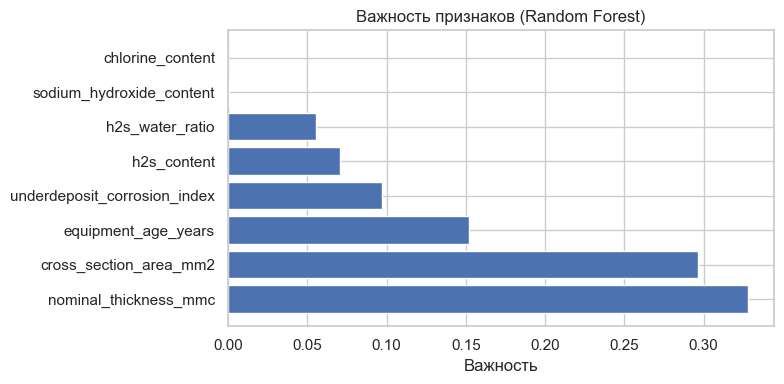

In [ ]:
# Важность признаков (feature importance)
imp_df = pd.DataFrame({
    'признак': FEATURES,
    'важность': model.feature_importances_
}).sort_values('важность', ascending=False)
print(imp_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(imp_df['признак'], imp_df['важность'])
ax.set_xlabel('Важность')
ax.set_title('Важность признаков (Random Forest)')
plt.tight_layout()
plt.show()